#California Wildfires Dataset (Dataset I)

##Schema of Dataset
#####AcresBurned - Acres of land affected by wildfires
#####Active - If the fire is active or contained?
#####ArchiveYear - Year the incident took place
#####CalFireIncident - Is the incident treated as a CalFire incident?
#####Counties - County name
#####CountyIds - County id
#####Latitude - Latitude of the Wildfire incident
####Location - Description of the location
#####Longitude - Longitude of the Wildfire incident
#####Name - Name of the fire incident
#####Status - Status of fire finalized or inactive



###Reading California forest fire dataset from drive.

In [1]:
from google.colab import drive
# NOTE: this will pop up asking for google login permission1
drive.mount('/content/drive')
# linux command to list the files under linux running
#Colab Jupyter notebook (prints dir/files/links in your Drive)
!ls -ltr /content/drive/MyDrive/ | grep *.csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ls: '/content/drive/MyDrive/dataset (1)': No such file or directory
ls: /content/drive/MyDrive/dataset_csv: No such file or directory
ls: /content/drive/MyDrive/dataset: No such file or directory
ls: '/content/drive/MyDrive/Dataset - 2024  - Food Production [SRM]': No such file or directory


In [2]:
!ls -ltr /content/drive/MyDrive/surya_data/California_Fire_Incidents_V1.csv

-rw------- 1 root root 203166 Jan  5  2023 /content/drive/MyDrive/surya_data/California_Fire_Incidents_V1.csv


In [3]:
import csv
import re
import random
import traceback
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xlrd
import glob
import numpy as np
import datetime
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.neural_network import MLPClassifier,MLPRegressor
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score
from sklearn import svm
from sklearn import metrics
from sklearn import preprocessing
from sklearn import linear_model
from scipy import stats
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neural_network import MLPClassifier

In [4]:
def pretty_print(df, n):
  print(tabulate(df.head(n),headers='keys',tablefmt='psql'))

In [5]:
df_california=pd.read_csv('/content/drive/MyDrive/surya_data/California_Fire_Incidents_V1.csv')
pretty_print(df_california,1)
print('Shape', df_california.shape)

+----+---------------+----------+---------------+-------------------+------------+-------------+------------+-----------------------------------------+-------------+----------+-----------+
|    |   AcresBurned | Active   |   ArchiveYear | CalFireIncident   | Counties   |   CountyIds |   Latitude | Location                                |   Longitude | Name     | Status    |
|----+---------------+----------+---------------+-------------------+------------+-------------+------------+-----------------------------------------+-------------+----------+-----------|
|  0 |        257314 | False    |          2013 | True              | Tuolumne   |          55 |     37.857 | 3 miles east of Groveland along Hwy 120 |    -120.086 | Rim Fire | Finalized |
+----+---------------+----------+---------------+-------------------+------------+-------------+------------+-----------------------------------------+-------------+----------+-----------+
Shape (1636, 11)


###Dtypes

In [6]:
df_california.info()
df_california.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AcresBurned      1633 non-null   float64
 1   Active           1636 non-null   bool   
 2   ArchiveYear      1636 non-null   int64  
 3   CalFireIncident  1636 non-null   bool   
 4   Counties         1636 non-null   object 
 5   CountyIds        1636 non-null   object 
 6   Latitude         1636 non-null   float64
 7   Location         1636 non-null   object 
 8   Longitude        1636 non-null   float64
 9   Name             1636 non-null   object 
 10  Status           1636 non-null   object 
dtypes: bool(2), float64(3), int64(1), object(5)
memory usage: 118.4+ KB


AcresBurned        float64
Active                bool
ArchiveYear          int64
CalFireIncident       bool
Counties            object
CountyIds           object
Latitude           float64
Location            object
Longitude          float64
Name                object
Status              object
dtype: object

###Data Statistics

In [7]:
df_california.describe().T

,count,mean,std,min,25%,50%,75%,max
AcresBurned,1633.0,4589.443968,27266.337722,0.00000,35.000000,100.000000,422.000000,410203.0000
ArchiveYear,1636.0,2016.608802,1.845340,2013.00000,2015.000000,2017.000000,2018.000000,2019.0000
Latitude,1636.0,37.203975,135.401380,-120.25800,34.165891,37.104065,39.086808,5487.0000
Longitude,1636.0,-108.082642,37.006927,-124.19629,-121.768358,-120.461560,-117.474073,118.9082


#

In [8]:
df_pca = df_california.copy()
df_pca['AcresBurned'] = df_pca['AcresBurned'].fillna(0)
print(df_pca)

      AcresBurned  Active  ArchiveYear  CalFireIncident     Counties  \
0        257314.0   False         2013             True     Tuolumne   
1         30274.0   False         2013             True  Los Angeles   
2         27531.0   False         2013             True    Riverside   
3         27440.0   False         2013            False       Placer   
4         24251.0   False         2013             True      Ventura   
...           ...     ...          ...              ...          ...   
1631          9.0   False         2019             True    Riverside   
1632          2.0   False         2019             True       Nevada   
1633          0.0   False         2019            False         Yolo   
1634          0.0   False         2019            False    San Diego   
1635          0.0   False         2019            False    Riverside   

     CountyIds   Latitude                                           Location  \
0           55  37.857000            3 miles east of Gr

<Figure size 1000x600 with 0 Axes>

<Axes: >

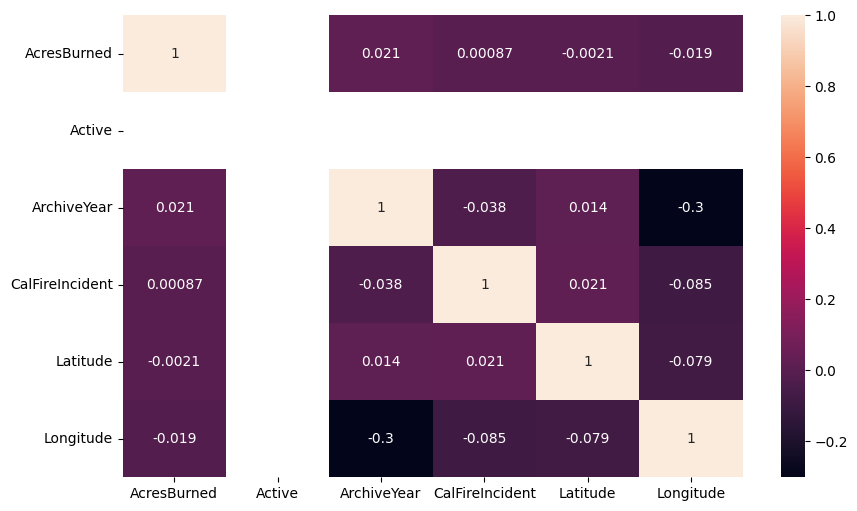

In [9]:
# Corelation Coefficient
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#corelation matrix
correlation = df_pca.corr()

#plotting heatmap
plt.figure(figsize = (10,6))
sns.heatmap(correlation, annot = True)

In [10]:
!pip install skfeature-chappers

#### Ordinal Encoding On Categorical Varibles for PCA.

In [11]:
# Ordinal encoding on multiple columns conversion of categorical to numeric values without labels
enc = OrdinalEncoder()
enc.fit(df_pca[["Active", "Name", "Status", "Location", "CalFireIncident", "Counties", "CountyIds"]])
df_pca[["Active", "Name", "Status", "Location", "CalFireIncident", "Counties", "CountyIds"]] = enc.transform(df_pca[["Active", "Name", "Status", "Location", "CalFireIncident", "Counties", "CountyIds"]])
pretty_print(df_pca, 10)

OrdinalEncoder()

+----+---------------+----------+---------------+-------------------+------------+-------------+------------+------------+-------------+--------+----------+
|    |   AcresBurned |   Active |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Location |   Longitude |   Name |   Status |
|----+---------------+----------+---------------+-------------------+------------+-------------+------------+------------+-------------+--------+----------|
|  0 |        257314 |        0 |          2013 |                 1 |         55 |          63 |    37.857  |         38 |    -120.086 |    882 |        0 |
|  1 |         30274 |        0 |          2013 |                 1 |         17 |          13 |    34.5856 |         67 |    -118.423 |    826 |        0 |
|  2 |         27531 |        0 |          2013 |                 1 |         32 |          36 |    33.7095 |        412 |    -116.729 |    720 |        0 |
|  3 |         27440 |        0 |          2013 |         

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_pca)
scaled_data_X = scaler.transform(df_pca)
scaled_data_Y = scaler.transform(df_pca)

StandardScaler()

In [13]:
from sklearn.decomposition import PCA

In [14]:
pca = PCA(n_components = 10, whiten = True)
pca.fit(scaled_data_X)
pca_X = pca.transform(scaled_data_X)

PCA(n_components=10, whiten=True)

In [15]:
pca_X_train, pca_X_test, pca_y_train, pca_y_test = train_test_split(scaled_data_X, scaled_data_Y, test_size = 0.2, random_state = 4)

In [16]:
pca_lr = LinearRegression()

# Train the model
pca_model = pca_lr.fit(pca_X_train, pca_y_train)

# Prediction
pca_y_pred =  pca_lr.predict(pca_X_test)

# Accuracy Score
pca_lr.score(pca_X_test, pca_y_test).round(4)

-0.2809

In [17]:
from sklearn.decomposition import PCA, TruncatedSVD

In [18]:
svd = TruncatedSVD(n_components = 10)
svd.fit(scaled_data_X)
svd_X = pca.transform(scaled_data_X)

TruncatedSVD(n_components=10)

In [19]:
svd_X_train, svd_X_test, svd_y_train, svd_y_test = train_test_split(scaled_data_X, scaled_data_Y, test_size = 0.2, random_state = 4)

In [20]:
svd_lr = LinearRegression()

# Train the model
svd_model = svd_lr.fit(svd_X_train, svd_y_train)

# Prediction
pca_y_pred =  svd_lr.predict(svd_X_test)

# Accuracy Score
svd_lr.score(svd_X_test, svd_y_test).round(4)

-0.2809

#

####Drop columns

In [21]:
df_california_v1 = df_california.drop(columns=['Active', 'Name','Status','Location'])
pretty_print(df_california_v1,1)
print("Shape:", df_california_v1.shape)

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear | CalFireIncident   | Counties   |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |        257314 |          2013 | True              | Tuolumne   |          55 |     37.857 |    -120.086 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
Shape: (1636, 7)


###Preprocessing Data

######Text data included with the numeric data(Counties). So we need to encode that in some numeric form before splitting the train test data.

In [22]:
df_explode_countyids = df_california_v1.copy()
pretty_print(df_explode_countyids,1)

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear | CalFireIncident   | Counties   |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |        257314 |          2013 | True              | Tuolumne   |          55 |     37.857 |    -120.086 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+


In [23]:
df_explode_countyids.dtypes

AcresBurned        float64
ArchiveYear          int64
CalFireIncident       bool
Counties            object
CountyIds           object
Latitude           float64
Longitude          float64
dtype: object

In [24]:
# Ordinalencoding on multiple columns conversion of categorical to numeric values without labels
enc = OrdinalEncoder()
enc.fit(df_explode_countyids[["CalFireIncident","Counties", "CountyIds"]])
df_explode_countyids[["CalFireIncident","Counties", "CountyIds"]] = enc.transform(df_explode_countyids[["CalFireIncident","Counties", "CountyIds"]])
pretty_print(df_explode_countyids, 10)

OrdinalEncoder()

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |        257314 |          2013 |                 1 |         55 |          63 |    37.857  |    -120.086 |
|  1 |         30274 |          2013 |                 1 |         17 |          13 |    34.5856 |    -118.423 |
|  2 |         27531 |          2013 |                 1 |         32 |          36 |    33.7095 |    -116.729 |
|  3 |         27440 |          2013 |                 0 |         30 |          34 |    39.12   |    -120.65  |
|  4 |         24251 |          2013 |                 1 |         56 |          64 |     0      |       0     |
|  5 |         22992 |          2013 |                 0 |          9 |           2 |    37.279 

In [25]:
#Label Encoding , is used only once on single column of dataframe, to use particular column as label.
label_encoder = LabelEncoder()

df_explode_countyids ['AcresBurned'] = label_encoder.fit_transform(df_explode_countyids['AcresBurned'])
pretty_print(df_explode_countyids,2)

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Longitude |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------|
|  0 |           631 |          2013 |                 1 |         55 |          63 |    37.857  |    -120.086 |
|  1 |           588 |          2013 |                 1 |         17 |          13 |    34.5856 |    -118.423 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+


In [26]:
def convert_list(row):
  mList = [int(e) if e.isdigit() else e for e in str(row['CountyIds']).split(',')]
  return mList

#Create new column to store value to str or int by passing function on dataframe
df_explode_countyids['CountyIds_new'] = df_explode_countyids.apply(convert_list, axis=1)
df_explode_countyids = df_explode_countyids.explode('CountyIds_new')
#pretty_print(df_explode_countyids,2)
df_explode_countyids.dtypes

AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
CountyIds          float64
Latitude           float64
Longitude          float64
CountyIds_new       object
dtype: object

In [27]:
def fill_na_0(row):
  if str(row['CountyIds_new']).isnumeric():
   return int(row['CountyIds_new'])
  else:
   return 0

df_explode_countyids['County_new_Ids'] = df_explode_countyids.apply(fill_na_0, axis=1)
pretty_print(df_explode_countyids,1)
df_explode_countyids.dtypes

+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+-----------------+------------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   CountyIds |   Latitude |   Longitude |   CountyIds_new |   County_new_Ids |
|----+---------------+---------------+-------------------+------------+-------------+------------+-------------+-----------------+------------------|
|  0 |           631 |          2013 |                 1 |         55 |          63 |     37.857 |    -120.086 |              63 |                0 |
+----+---------------+---------------+-------------------+------------+-------------+------------+-------------+-----------------+------------------+


AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
CountyIds          float64
Latitude           float64
Longitude          float64
CountyIds_new       object
County_new_Ids       int64
dtype: object

In [28]:
df_explode_countyids = df_explode_countyids.drop(columns=['CountyIds','CountyIds_new'])
# pretty_print(df_explode_countyids,2)
df_explode_countyids.dtypes

AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
Latitude           float64
Longitude          float64
County_new_Ids       int64
dtype: object

In [29]:
#df_explode_countyids.fillna(0, inplace=True)

In [30]:
#created new function for lambda
m = df_explode_countyids['AcresBurned'].mean()
print("mean",m)

sd = df_explode_countyids['AcresBurned'].std()
print("standard deviation",sd)

def lambda_dup(df_explode_countyids):
  if (df_explode_countyids['AcresBurned'] == 0):
        return 0
  elif (df_explode_countyids['AcresBurned'] <= m + 1*sd):
        return 1
  elif (df_explode_countyids['AcresBurned'] <= m+ 2*sd):
        return 2
  elif (df_explode_countyids['AcresBurned'] <= m + 3*sd):
        return 3
  else:
        return 0

mean 172.56112469437653
standard deviation 182.75698824062303


In [31]:
df_explode_countyids['lambda_dup_num'] = df_explode_countyids.apply(lambda_dup, axis=1)
pretty_print(df_explode_countyids,1)
df_explode_countyids.dtypes

+----+---------------+---------------+-------------------+------------+------------+-------------+------------------+------------------+
|    |   AcresBurned |   ArchiveYear |   CalFireIncident |   Counties |   Latitude |   Longitude |   County_new_Ids |   lambda_dup_num |
|----+---------------+---------------+-------------------+------------+------------+-------------+------------------+------------------|
|  0 |           631 |          2013 |                 1 |         55 |     37.857 |    -120.086 |                0 |                3 |
+----+---------------+---------------+-------------------+------------+------------+-------------+------------------+------------------+


AcresBurned          int64
ArchiveYear          int64
CalFireIncident    float64
Counties           float64
Latitude           float64
Longitude          float64
County_new_Ids       int64
lambda_dup_num       int64
dtype: object

In [32]:
def ordinal_encoding(df_explode_countyids,column,ordering):
  df_explode_countyids = df_explode_countyids.copy()
  df_explode_countyids[column] = df_explode_countyids[column].apply(lambda_dup)
  return df_explode_countyids

In [33]:
def preprocessing(df_explode_countyids,task):
  df_explode_countyids=df_explode_countyids.copy()

  if task=='Regression':
    Y=df_explode_countyids['lambda_dup_num']
  elif task=='Classification':
    Y=df_explode_countyids['lambda_dup_num']

  X=df_explode_countyids.drop(['lambda_dup_num','AcresBurned'],axis=1)

  X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.65,shuffle=True,random_state=1)

  scaler=StandardScaler()
  scaler.fit(X_train)

  X_train=pd.DataFrame(scaler.transform(X_train),columns=X.columns)
  X_test=pd.DataFrame(scaler.transform(X_test),columns=X.columns)
  return X_train,X_test,Y_train,Y_test

####Splitting & Testing Models:

In [34]:
X_train, X_test, Y_train, Y_test = preprocessing(df_explode_countyids, task='Classification')
X_train.head(1)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

,ArchiveYear,CalFireIncident,Counties,Latitude,Longitude,County_new_Ids
0,1.292532,0.560328,0.108824,0.373163,-0.351624,0.0


(1063, 6) (573, 6) (1063,) (573,)


In [35]:
df_explode_countyids["lambda_dup_num"].value_counts()

1    1294
2     202
3     112
0      28
Name: lambda_dup_num, dtype: int64

In [36]:
dfc = df_explode_countyids.copy()
print(dfc)

      AcresBurned  ArchiveYear  CalFireIncident  Counties   Latitude  \
0             631         2013              1.0      55.0  37.857000   
1             588         2013              1.0      17.0  34.585595   
2             584         2013              1.0      32.0  33.709500   
3             583         2013              0.0      30.0  39.120000   
4             580         2013              1.0      56.0   0.000000   
...           ...          ...              ...       ...        ...   
1631            3         2019              1.0      32.0  33.827979   
1632            1         2019              1.0      28.0  39.409722   
1633          634         2019              0.0      57.0  38.734634   
1634          634         2019              0.0      36.0  33.351145   
1635          634         2019              0.0      32.0  33.451480   

       Longitude  County_new_Ids  lambda_dup_num  
0    -120.086000               0               3  
1    -118.423176               0 

###Feature Importance

In [ ]:
print(df_explode_countyids)

RandomForestClassifier()

Feature Importance:
           Feature  Importance
4        Longitude    0.323762
3         Latitude    0.320862
2         Counties    0.196422
0      ArchiveYear    0.097929
6   lambda_dup_num    0.047364
1  CalFireIncident    0.013661
5   County_new_Ids    0.000000


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 7 artists>

Text(0.5, 0, 'Importance')

Text(0, 0.5, 'Feature')

Text(0.5, 1.0, 'Feature Importance')

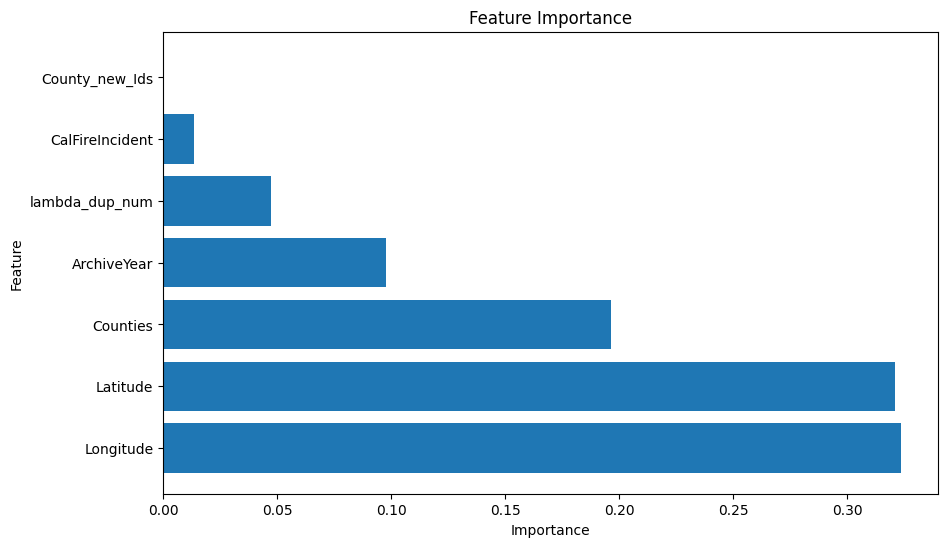

In [41]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Assuming you have your dataset loaded into a pandas DataFrame: df

# Separate features and target variable
X = df_explode_countyids.drop(columns=['AcresBurned'])  # Features
y = df_explode_countyids['AcresBurned']  # Target variable

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Fit the classifier to the data
rf_classifier.fit(X, y)

# Get feature importances
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame to store feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print or visualize feature importances
print("Feature Importance:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()
